## In this notebook, Im undersampling the dataset to maintain class balance, and avoiding the super minority classes.

This Assignment belongs to Team-16. 
160123748047, 048, 049

In [1]:
import requests

train_url = "https://huggingface.co/api/datasets/ai4bharat/indic_glue/parquet/bbca.hi/train"
test_url = "https://huggingface.co/api/datasets/ai4bharat/indic_glue/parquet/bbca.hi/test"

In [2]:
import requests
import pandas as pd

def load_parquet_from_api(api_url, filename="test.parquet"):
    response = requests.get(api_url)
    data = response.json()
    
    parquet_url = data[0]
    
    file_data = requests.get(parquet_url)
    
    with open(filename, "wb") as f:
        f.write(file_data.content)
    
    df = pd.read_parquet(filename)
    return df

In [3]:
df = load_parquet_from_api("https://huggingface.co/api/datasets/ai4bharat/indic_glue/parquet/bbca.hi/train")

In [4]:
print(df.head())

      label                                               text
0     india  मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...
1  pakistan  नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...
2      news  इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...
3     india  प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ...
4     india  ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3467 entries, 0 to 3466
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   3467 non-null   object
 1   text    3467 non-null   object
dtypes: object(2)
memory usage: 54.3+ KB


In [6]:
label_counts = df['label'].value_counts()
print(label_counts)

label
india              1389
international       904
entertainment       285
sport               258
news                230
science             194
business             54
pakistan             43
southasia            42
institutional        19
social               18
china                14
multimedia           12
learningenglish       5
Name: count, dtype: int64


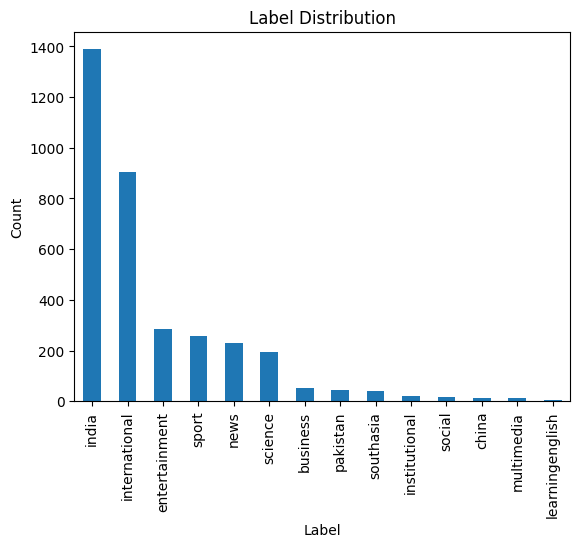

In [7]:
import matplotlib.pyplot as plt

label_counts.plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [8]:
import pandas as pd

# Step 1: filter classes >= 190
label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts >= 190].index

df_filtered = df[df['label'].isin(valid_labels)]

# Step 2: balance dataset
def balance_class(group):
    if group.name in ['india', 'international']:
        return group.sample(400, random_state=42)
    return group

df_balanced = df_filtered.groupby('label').apply(balance_class).reset_index(drop=True)

# Step 3: check result
print(df_balanced['label'].value_counts())

label
india            400
international    400
entertainment    285
sport            258
news             230
science          194
Name: count, dtype: int64


/tmp/ipykernel_24/1972818307.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_filtered.groupby('label').apply(balance_class).reset_index(drop=True)


In [9]:
test_df = load_parquet_from_api(test_url)
valid_labels = ['india', 'international', 'entertainment', 'sport', 'news', 'science']
test_df = test_df[test_df['label'].isin(valid_labels)].copy()
test_df['label'].value_counts()

label
india            357
international    212
sport             72
entertainment     71
science           61
news              49
Name: count, dtype: int64

## Logistic Regression

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df_balanced['text'])
y = df_balanced['label']

In [11]:
X_test = vectorizer.transform(test_df['text'])
y_test = test_df['label']

In [12]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(class_weight='balanced', max_iter=1000)

In [13]:
logreg_model.fit(X, y)
preds = logreg_model.predict(X_test)

In [14]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy: 0.718978102189781

Classification Report:

               precision    recall  f1-score   support

entertainment       0.64      0.80      0.71        71
        india       0.91      0.70      0.79       357
international       0.67      0.66      0.66       212
         news       0.39      0.63      0.48        49
      science       0.57      0.85      0.68        61
        sport       0.80      0.88      0.83        72

     accuracy                           0.72       822
    macro avg       0.66      0.75      0.69       822
 weighted avg       0.76      0.72      0.73       822



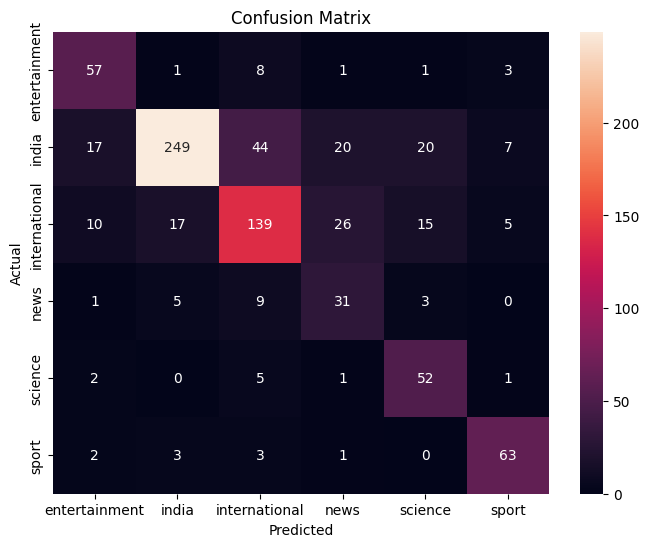

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=logreg_model.classes_, yticklabels=logreg_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
foreign_text = "पाकिस्तान क्रिकेट बोर्ड (PCB) के मेडिकल पैनल ने खुलासा किया है कि बाबर आजम और फखर जमान को टी-20 वर्ल्ड कप टीम में शामिल किए जाने के समय उनकी फिटनेस पूरी तरह ठीक नहीं थी। पैनल के मुताबिक, दोनों खिलाड़ी चोट से पूरी तरह उबर नहीं पाए थे, इसके बावजूद उनका चयन किया गया। इस मामले को लेकर सीनियर सेलेक्टर आकिब जावेद ने भी पिछले हफ्ते प्रेस कॉन्फ्रेंस में सवाल उठाए थे और चयन प्रक्रिया की जांच की मांग की थी।"

In [17]:
import numpy as np
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\u0900-\u097F\s]', '', text)  # keep Hindi chars only
    return text
def inference(text, model, vectorizer):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    
    probs = model.predict_proba(vec)[0]
    classes = model.classes_
    
    for cls, p in zip(classes, probs):
        print(f"{cls}: {p:.3f}")
    
    print("\nFinal Prediction:", classes[np.argmax(probs)])
inference(foreign_text, logreg_model, vectorizer)

entertainment: 0.155
india: 0.107
international: 0.103
news: 0.153
science: 0.136
sport: 0.346

Final Prediction: sport


In [18]:
international_foreign_text = """अमेरिका के राष्ट्रपति ट्रम्प ने सोमवार को ओवल ऑफिस में पत्रकारों से बात करते हुए कहा कि वह ‘क्यूबा को अपने कब्जे में लेने’ का इरादा रखते हैं। उन्होंने कहा, “किसी न किसी रूप में क्यूबा को लूंगा… चाहे मैं उसे आजाद करूं या अपने नियंत्रण में ले लूं। मैं उसके साथ कुछ भी कर सकता हूं।
न्यूयॉर्क टाइम्स के मुताबिक ट्रम्प के इस बयान को काफी चौंकाने वाला माना जा रहा है। अमेरिका के इतिहास में कई राष्ट्रपति क्यूबा के साथ तनावपूर्ण रिश्तों में रहे हैं, लेकिन किसी ने भी इस तरह खुलेतौर पर क्यूबा पर कब्जा करने की बात नहीं कही थी"""
inference(international_foreign_text, logreg_model, vectorizer)

entertainment: 0.167
india: 0.068
international: 0.376
news: 0.316
science: 0.031
sport: 0.042

Final Prediction: international


In [19]:
film_news_foreign = """धुरंधर 2 के ट्रेलर ने लोगों की एक्सपेक्टेशन को हाई कर दिया है. जैसा कि मेकर्स ने वादा किया था इस बार डबल एक्शन और थ्रिलर देखने को मिलेगा. सेकंड पार्ट में हमजा (रणवीर सिंह) की ल्यारी पर अपना कब्जा जमाने और आतंकियों के खात्मे की कहानी दिखाई जाएगी. हमजा के जसकीरत सिंह रंगी बनने की जर्नी देखने को मिलेगी. मूवी में रणवीर सिंह, संजय दत्त, सारा अर्जुन, अर्जुन रामपाल, आर माधवन अहम रोल में दिखेंगे."""
inference(film_news_foreign, logreg_model, vectorizer)

entertainment: 0.294
india: 0.124
international: 0.088
news: 0.230
science: 0.073
sport: 0.191

Final Prediction: entertainment


### Okay now I will try N-grams with same LogReg.. and then SVM maybe

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

ngram_vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2)
)

In [21]:
X = ngram_vectorizer.fit_transform(df_balanced['text'])
y = df_balanced['label']

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

ngram_logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)
ngram_logreg.fit(X, y)

svm_model = LinearSVC(
    class_weight='balanced',
    max_iter=2000
)
svm_model.fit(X, y)

LinearSVC(class_weight='balanced', max_iter=2000)

In [23]:
X_test = ngram_vectorizer.transform(test_df['text'])
y_test = test_df['label']

In [24]:
# ngram + TF-IDF + LogReg
logreg_ngram_preds = ngram_logreg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, logreg_ngram_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy: 0.7360097323600974

Classification Report:

               precision    recall  f1-score   support

entertainment       0.64      0.80      0.71        71
        india       0.91      0.70      0.79       357
international       0.67      0.66      0.66       212
         news       0.39      0.63      0.48        49
      science       0.57      0.85      0.68        61
        sport       0.80      0.88      0.83        72

     accuracy                           0.72       822
    macro avg       0.66      0.75      0.69       822
 weighted avg       0.76      0.72      0.73       822



In [25]:
# ngram + TF-IDF + SVM
svm_ngram_preds = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, svm_ngram_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy: 0.7530413625304136

Classification Report:

               precision    recall  f1-score   support

entertainment       0.64      0.80      0.71        71
        india       0.91      0.70      0.79       357
international       0.67      0.66      0.66       212
         news       0.39      0.63      0.48        49
      science       0.57      0.85      0.68        61
        sport       0.80      0.88      0.83        72

     accuracy                           0.72       822
    macro avg       0.66      0.75      0.69       822
 weighted avg       0.76      0.72      0.73       822



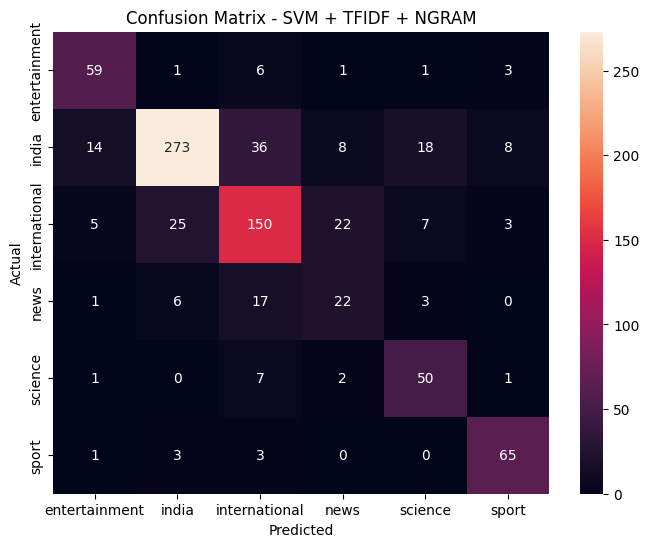

In [26]:
cm = confusion_matrix(y_test, svm_ngram_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM + TFIDF + NGRAM")
plt.show()

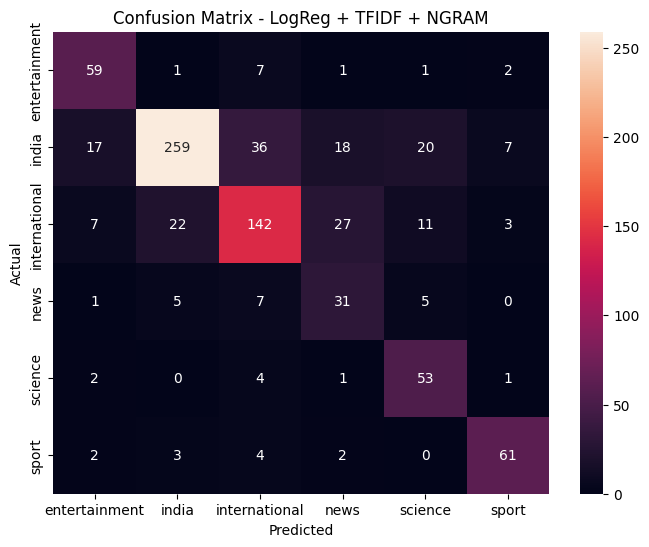

In [27]:
cm = confusion_matrix(y_test, logreg_ngram_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=logreg_model.classes_, yticklabels=logreg_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LogReg + TFIDF + NGRAM")
plt.show()

We see huge mis-classification between international and india topics, and also we see misclassification between international and news topics!! I see. Further, We will find out a way to better understand the text and categorize the text. 